In [2]:
# Install required packages
!pip install tensorflow pandas scikit-learn matplotlib pillow

import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [7]:
import zipfile
import pandas as pd
import numpy as np
from PIL import Image
import io
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt



In [8]:

# Path to ZIP file
zip_path = '/content/archive (1).zip'


In [9]:

# Load ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # Step 1: Check CSV structure
    with zip_ref.open('english.csv') as f:
        df = pd.read_csv(f)
        print("CSV Columns:", df.columns.tolist())
        print(df.head())

    # Try common column names if 'image' isn't found
    image_col = None
    for col in ['image', 'filename', 'Image', 'Image_Name']:
        if col in df.columns:
            image_col = col
            break

    label_col = None
    for col in ['label', 'Label', 'character', 'Character']:
        if col in df.columns:
            label_col = col
            break

    if not image_col or not label_col:
        raise ValueError("Image or label column not found in CSV!")


CSV Columns: ['image', 'label']
                image label
0  Img/img001-001.png     0
1  Img/img001-002.png     0
2  Img/img001-003.png     0
3  Img/img001-004.png     0
4  Img/img001-005.png     0


In [15]:
# Load ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # Step 1: Check CSV structure
    with zip_ref.open('english.csv') as f:
        df = pd.read_csv(f)
        print("CSV Columns:", df.columns.tolist())
        print(df.head())

    # Try common column names if 'image' isn't found
    image_col = None
    for col in ['image', 'filename', 'Image', 'Image_Name']:
        if col in df.columns:
            image_col = col
            break

    label_col = None
    for col in ['label', 'Label', 'character', 'Character']:
        if col in df.columns:
            label_col = col
            break

    if not image_col or not label_col:
        raise ValueError("Image or label column not found in CSV!")

    # Step 2: Load images
    images, labels = [], []
    for idx, row in df.iterrows():
        # **Change 1: Remove the 'Img/' prefix from the image path if it is already included in the CSV**
        # Assuming the image column contains full paths like 'Img/img001.png'
        img_name = row[image_col]

        if img_name in zip_ref.namelist():
            with zip_ref.open(img_name) as img_file:
                try:
                    img = Image.open(img_file).convert('L').resize((64, 64))
                    images.append(np.array(img))
                    labels.append(row[label_col])
                except Exception as e:
                    print(f"Error loading {img_name}: {e}")
        else:
            print(f"Missing image: {img_name}")
# Check if any images loaded
if len(images) == 0:
  raise ValueError("No images loaded. Check ZIP structure and CSV columns.")


CSV Columns: ['image', 'label']
                image label
0  Img/img001-001.png     0
1  Img/img001-002.png     0
2  Img/img001-003.png     0
3  Img/img001-004.png     0
4  Img/img001-005.png     0


In [16]:

# Continue with preprocessing and model training
X = np.array(images).reshape(-1, 64, 64, 1) / 255.0
label_list = sorted(list(set(labels)))
label_to_index = {label: i for i, label in enumerate(label_list)}
y = np.array([label_to_index[label] for label in labels])
y = to_categorical(y)


In [17]:

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:

# Build model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(label_list), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,632,574 (6.23 MB)

 Trainable params: 1,632,574 (6.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.0226 - loss: 4.1732 - val_accuracy: 0.0861 - val_loss: 3.9098
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.0985 - loss: 3.6961 - val_accuracy: 0.2527 - val_loss: 3.1301
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.2442 - loss: 2.9520 - val_accuracy: 0.3901 - val_loss: 2.5643
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.3384 - loss: 2.4968 - val_accuracy: 0.4414 - val_loss: 2.2293
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.4448 - loss: 2.0337 - val_accuracy: 0.4707 - val_loss: 2.0395
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.5287 - loss: 1.6902 - val_accuracy: 0.5549 - val_loss: 1.8687
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.5588 - loss: 1.5135 - val_accuracy: 0.5604 - val_loss: 1.7504
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.6580 - loss: 1.1930 - val_accuracy: 0.5

In [19]:

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5548 - loss: 1.5970
Test Accuracy: 0.58


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


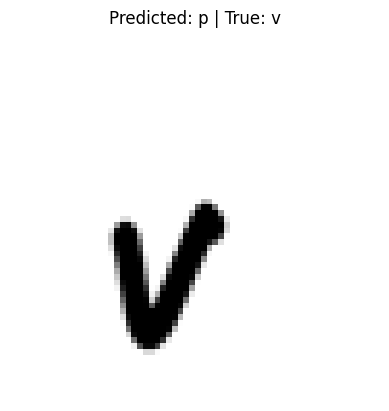

In [23]:
# Create reverse mapping from index to label
index_to_label = {v: k for k, v in label_to_index.items()}

# Pick a test sample
sample_index = 0  # Try other values like 1, 2, 10, etc.
sample_image = X_test[sample_index].reshape(1, 64, 64, 1)
true_label_index = np.argmax(y_test[sample_index])

# Predict
prediction = model.predict(sample_image)
predicted_index = np.argmax(prediction[0])

# Decode labels
predicted_label = index_to_label[predicted_index]
true_label = index_to_label[true_label_index]

# Show result
import matplotlib.pyplot as plt

plt.imshow(sample_image.reshape(64, 64), cmap='gray')
plt.title(f"Predicted: {predicted_label} | True: {true_label}")
plt.axis('off')
plt.show()


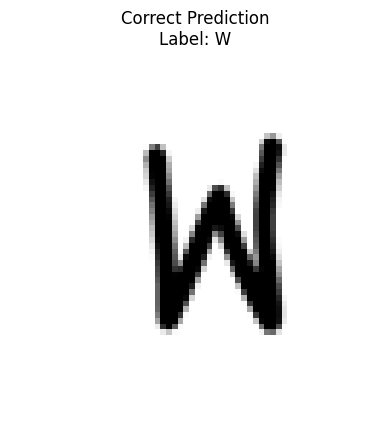

In [24]:
# Create reverse mapping from index to label
index_to_label = {v: k for k, v in label_to_index.items()}

# Search for a correct prediction
for i in range(len(X_test)):
    sample_image = X_test[i].reshape(1, 64, 64, 1)
    true_index = np.argmax(y_test[i])

    prediction = model.predict(sample_image, verbose=0)
    predicted_index = np.argmax(prediction[0])

    if predicted_index == true_index:
        # Match found — decode labels
        predicted_label = index_to_label[predicted_index]
        true_label = index_to_label[true_index]

        # Display the image and prediction
        import matplotlib.pyplot as plt
        plt.imshow(sample_image.reshape(64, 64), cmap='gray')
        plt.title(f"Correct Prediction\nLabel: {predicted_label}")
        plt.axis('off')
        plt.show()
        break
